In [3]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

# Your EIA key is broken in .env (saved as a URL by accident)
# Paste just the key here for tonight — we'll fix .env later this week
EIA_KEY = "LimV0pWe8C2RMfVbepm8US8w3LL6DtPGSgPRNv4l"

print("Key starts with:", EIA_KEY[:8])
print("Key length:", len(EIA_KEY), "characters")




Key starts with: LimV0pWe
Key length: 40 characters


In [4]:
url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

params = {
    "api_key": EIA_KEY,
    "frequency": "hourly",
    "data[0]": "value",
    "facets[respondent][]": "CAL",
    "facets[type][]": "D",            # D = Demand only (filters out forecast, generation, interchange)
    "start": "2024-01-01T00",
    "end": "2025-01-01T00",
    "length": 5000,                    # Max records per request
    "offset": 0
}

# EIA caps responses at 5000 rows. A year of hourly data is ~8760 rows.
# So we need 2 requests (offset 0 and offset 5000) and combine them.

all_data = []

for offset in [0, 5000]:
    params["offset"] = offset
    print(f"Pulling rows starting at offset {offset}...")
    response = requests.get(url, params=params)
    print(f"  Status: {response.status_code}")
    
    if response.status_code == 200:
        chunk = response.json()["response"]["data"]
        print(f"  Got {len(chunk)} rows")
        all_data.extend(chunk)
    else:
        print(f"  Error: {response.text[:200]}")
        break

print(f"\nTotal rows collected: {len(all_data)}")

Pulling rows starting at offset 0...
  Status: 200
  Got 5000 rows
Pulling rows starting at offset 5000...
  Status: 200
  Got 3785 rows

Total rows collected: 8785


In [5]:
# Convert list of dicts to DataFrame
df = pd.DataFrame(all_data)
print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn types:")
print(df.dtypes)

Shape: (8785, 7)

First 3 rows:
          period respondent respondent-name type type-name  value  \
0  2025-01-01T00        CAL      California    D    Demand  28915   
1  2024-12-31T23        CAL      California    D    Demand  29337   
2  2024-12-31T22        CAL      California    D    Demand  30288   

     value-units  
0  megawatthours  
1  megawatthours  
2  megawatthours  

Column types:
period             object
respondent         object
respondent-name    object
type               object
type-name          object
value              object
value-units        object
dtype: object


In [6]:
# Convert value from string to number
df["value"] = pd.to_numeric(df["value"])

# Convert period from string to datetime
df["period"] = pd.to_datetime(df["period"], format="%Y-%m-%dT%H")

# Keep only the columns we care about and rename
df = df[["period", "value"]].rename(columns={"value": "demand_mwh"})

# Sort chronologically (oldest first)
df = df.sort_values("period").reset_index(drop=True)

# Set period as the index — this is the pandas-standard way to handle time series
df = df.set_index("period")

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nLast 3 rows:")
print(df.tail(3))
print("\nData type:", df["demand_mwh"].dtype)

Shape: (8785, 1)

First 3 rows:
                     demand_mwh
period                         
2024-01-01 00:00:00       28114
2024-01-01 01:00:00       28262
2024-01-01 02:00:00       29413

Last 3 rows:
                     demand_mwh
period                         
2024-12-31 22:00:00       30288
2024-12-31 23:00:00       29337
2025-01-01 00:00:00       28915

Data type: int64


In [7]:
import os

# Make sure the data folder exists
os.makedirs("data/raw", exist_ok=True)

# Save to CSV (with the datetime index preserved)
df.to_csv("data/raw/eia_ca_demand_2024.csv")

print("Saved to data/raw/eia_ca_demand_2024.csv")
print("\nBasic stats:")
print(df["demand_mwh"].describe())
print("\nAny missing values?", df["demand_mwh"].isna().sum())

Saved to data/raw/eia_ca_demand_2024.csv

Basic stats:
count     8785.000000
mean     30771.497325
std       5936.378370
min      18941.000000
25%      26596.000000
50%      29476.000000
75%      32971.000000
max      58867.000000
Name: demand_mwh, dtype: float64

Any missing values? 0


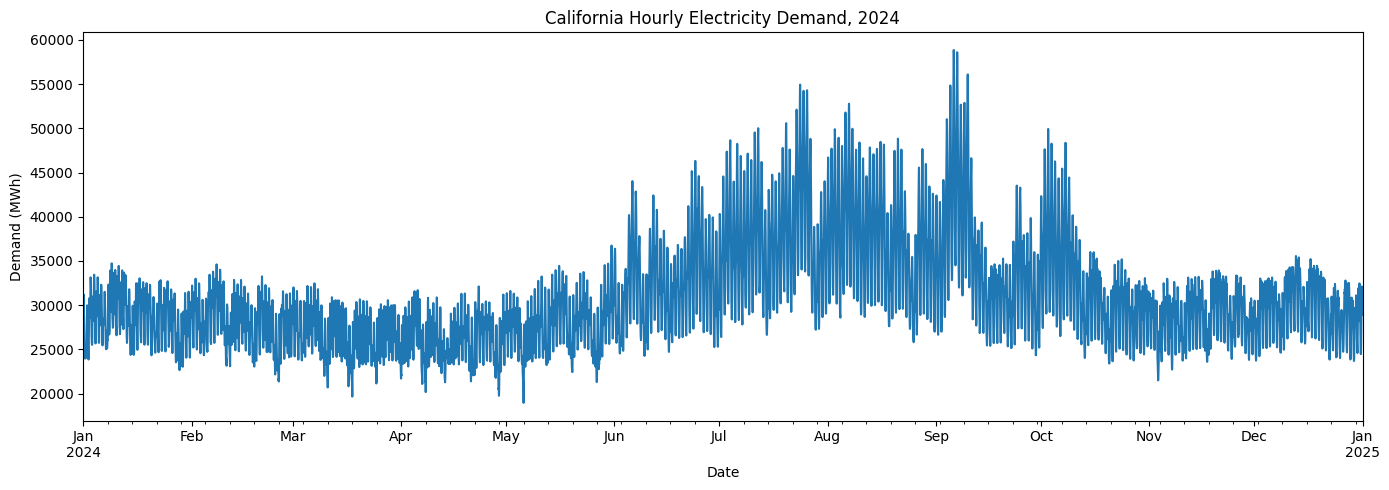

In [8]:
import matplotlib.pyplot as plt

# Plot the full year
fig, ax = plt.subplots(figsize=(14, 5))
df["demand_mwh"].plot(ax=ax)
ax.set_title("California Hourly Electricity Demand, 2024")
ax.set_ylabel("Demand (MWh)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

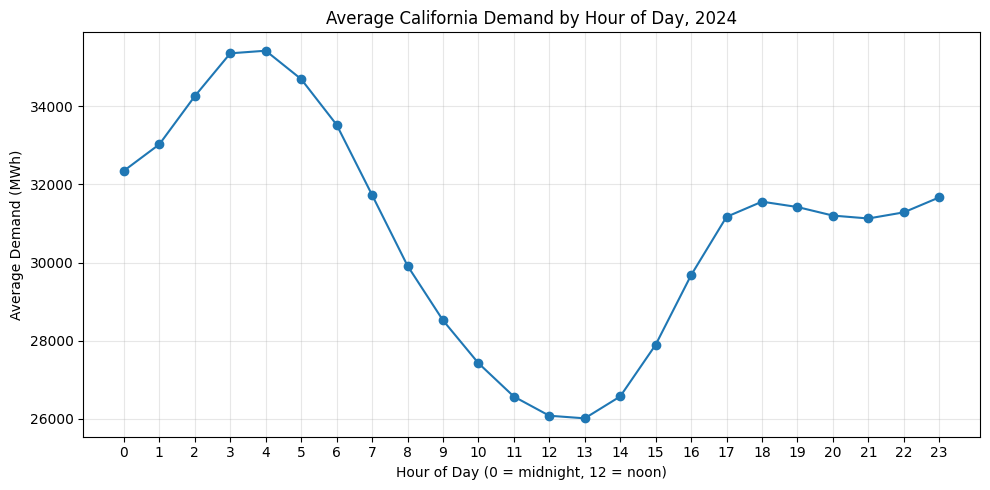

In [9]:
# Plot demand by hour-of-day (average daily pattern)
hourly_avg = df.groupby(df.index.hour)["demand_mwh"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
hourly_avg.plot(ax=ax, marker='o')
ax.set_title("Average California Demand by Hour of Day, 2024")
ax.set_xlabel("Hour of Day (0 = midnight, 12 = noon)")
ax.set_ylabel("Average Demand (MWh)")
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Timestamps came back in UTC — convert to Pacific time
df.index = df.index.tz_localize('UTC').tz_convert('US/Pacific')

# Re-save the corrected data
df.to_csv("data/raw/eia_ca_demand_2024.csv")
print(df.head(3))
print(df.tail(3))


                           demand_mwh
period                               
2023-12-31 16:00:00-08:00       28114
2023-12-31 17:00:00-08:00       28262
2023-12-31 18:00:00-08:00       29413
                           demand_mwh
period                               
2024-12-31 14:00:00-08:00       30288
2024-12-31 15:00:00-08:00       29337
2024-12-31 16:00:00-08:00       28915


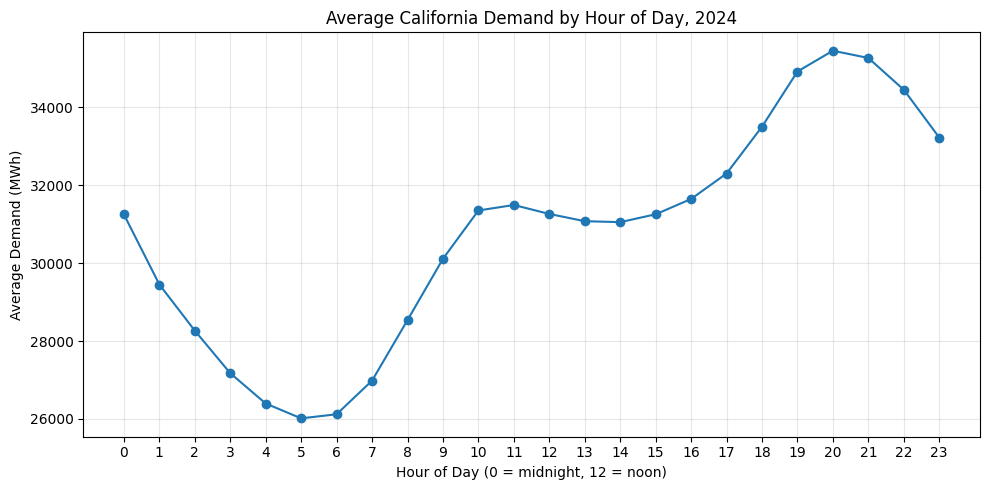

In [11]:
hourly_avg = df.groupby(df.index.hour)["demand_mwh"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
hourly_avg.plot(ax=ax, marker='o')
ax.set_title("Average California Demand by Hour of Day, 2024")
ax.set_xlabel("Hour of Day (0 = midnight, 12 = noon)")
ax.set_ylabel("Average Demand (MWh)")
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

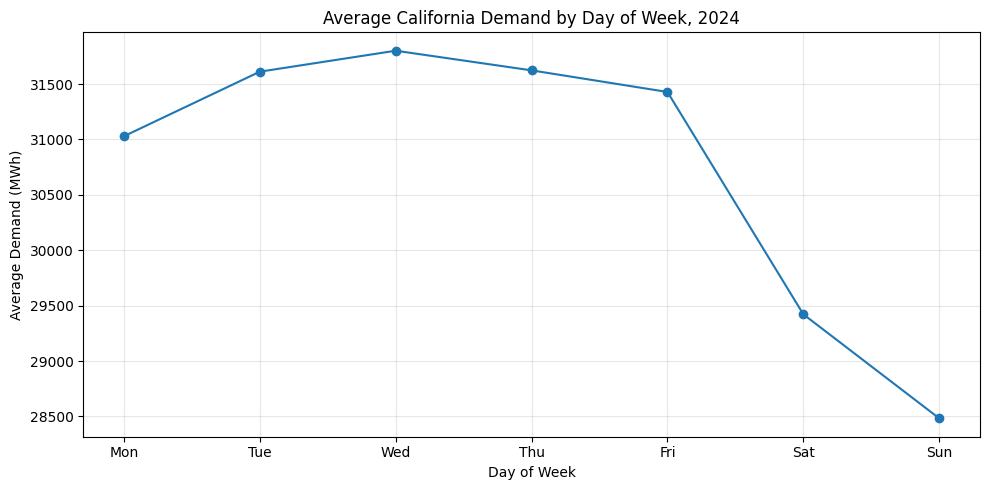

In [12]:
# Plot demand by day of week
dow_avg = df.groupby(df.index.dayofweek)["demand_mwh"].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 5))
dow_avg.plot(ax=ax, marker='o')
ax.set_title("Average California Demand by Day of Week, 2024")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Demand (MWh)")
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

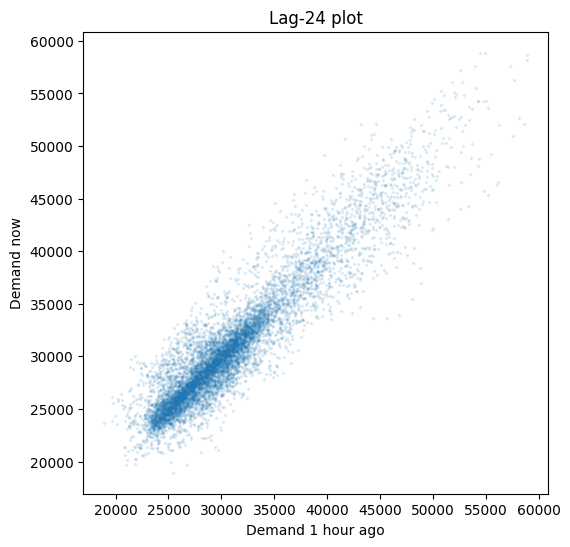

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["demand_mwh"].shift(24), df["demand_mwh"], alpha=0.1, s=2)
ax.set_xlabel("Demand 1 hour ago")
ax.set_ylabel("Demand now")
ax.set_title("Lag-24 plot")
plt.show()

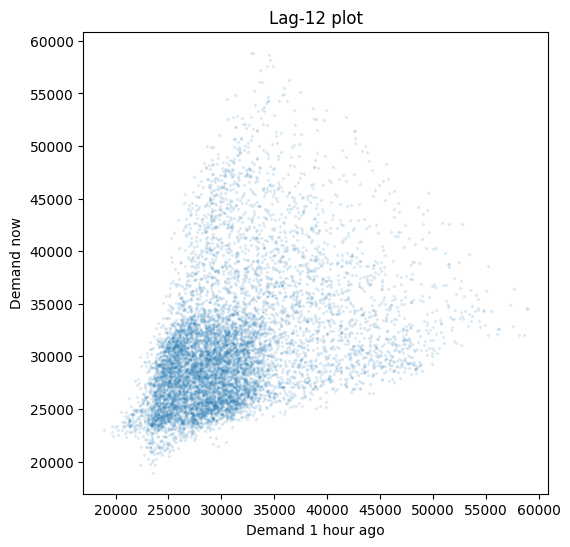

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["demand_mwh"].shift(12), df["demand_mwh"], alpha=0.1, s=2)
ax.set_xlabel("Demand 1 hour ago")
ax.set_ylabel("Demand now")
ax.set_title("Lag-12 plot")
plt.show()

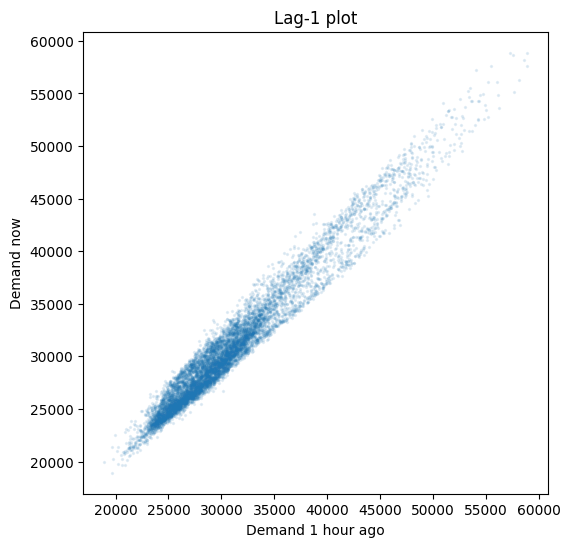

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["demand_mwh"].shift(1), df["demand_mwh"], alpha=0.1, s=2)
ax.set_xlabel("Demand 1 hour ago")
ax.set_ylabel("Demand now")
ax.set_title("Lag-1 plot")
plt.show()

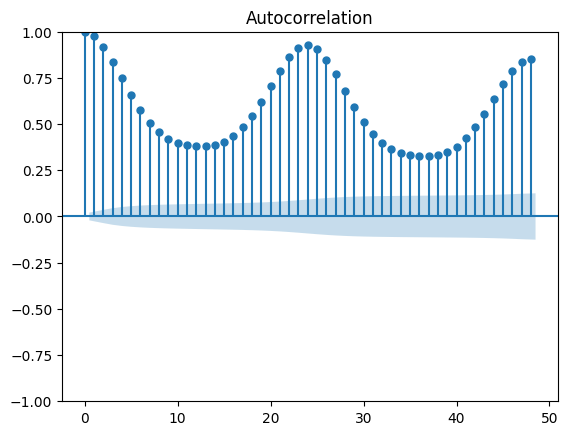

In [26]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df["demand_mwh"], lags=48)
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/raw/eia_ca_demand_2024.csv",
    index_col=0,
    parse_dates=True
)
print(df.shape)
print(df.index.dtype)
print(df.head(2))

(8785, 1)
object
                           demand_mwh
period                               
2023-12-31 16:00:00-08:00       28114
2023-12-31 17:00:00-08:00       28262


In [3]:
df.index = pd.to_datetime(df.index, utc=True).tz_convert('US/Pacific')
print(df.index.dtype)
print(df.head(2))

datetime64[ns, US/Pacific]
                           demand_mwh
period                               
2023-12-31 16:00:00-08:00       28114
2023-12-31 17:00:00-08:00       28262


In [6]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["demand_mwh"], period=24, robust=True)
result = stl.fit()

print(type(result))
print(dir(result))

<class 'statsmodels.tsa.seasonal.DecomposeResult'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_observed', '_resid', '_seasonal', '_trend', '_weights', 'nobs', 'observed', 'plot', 'resid', 'seasonal', 'trend', 'weights']


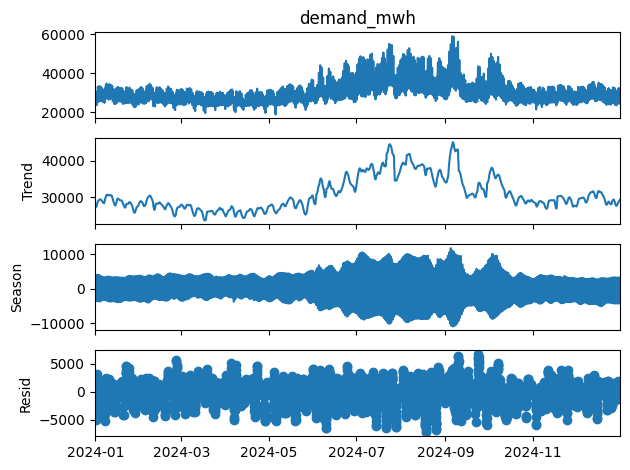

In [7]:
result.plot()
plt.tight_layout()
plt.show()

In [8]:
trend = result.trend
seasonal = result.seasonal
residual = result.resid

print("Trend - first 3 values:")
print(trend.head(3))
print("\nSeasonal - first 3 values:")
print(seasonal.head(3))
print("\nResidual - first 3 values:")
print(residual.head(3))

# Verify they add up to original
reconstructed = trend + seasonal + residual
print("\nMax reconstruction error:", 
      (df["demand_mwh"] - reconstructed).abs().max())

Trend - first 3 values:
period
2023-12-31 16:00:00-08:00    27428.303948
2023-12-31 17:00:00-08:00    27427.509100
2023-12-31 18:00:00-08:00    27426.437678
Name: trend, dtype: float64

Seasonal - first 3 values:
period
2023-12-31 16:00:00-08:00     822.052778
2023-12-31 17:00:00-08:00    1088.057032
2023-12-31 18:00:00-08:00    2270.424922
Name: season, dtype: float64

Residual - first 3 values:
period
2023-12-31 16:00:00-08:00   -136.356726
2023-12-31 17:00:00-08:00   -253.566132
2023-12-31 18:00:00-08:00   -283.862600
Name: resid, dtype: float64

Max reconstruction error: 7.275957614183426e-12


In [9]:
# Find the seasonal value at 5 AM on a specific day
mask = (df.index.hour == 5) & (df.index.month == 6)
print(seasonal[mask].head(5))

period
2024-06-01 05:00:00-07:00   -3715.384658
2024-06-02 05:00:00-07:00   -4044.828952
2024-06-03 05:00:00-07:00   -4706.444206
2024-06-04 05:00:00-07:00   -5644.536106
2024-06-05 05:00:00-07:00   -6223.060963
Name: season, dtype: float64


In [10]:
# Find the most anomalous days — largest absolute residuals
residual_daily_max = residual.resample('D').apply(lambda x: x.abs().max())
top_anomalies = residual_daily_max.nlargest(10)
print("Top 10 most anomalous days:")
print(top_anomalies.round(0))


Top 10 most anomalous days:
period
2024-08-18 00:00:00-07:00    7304.0
2024-08-25 00:00:00-07:00    6826.0
2024-09-23 00:00:00-07:00    6728.0
2024-06-09 00:00:00-07:00    6565.0
2024-07-21 00:00:00-07:00    6499.0
2024-09-09 00:00:00-07:00    6402.0
2024-07-28 00:00:00-07:00    6384.0
2024-09-24 00:00:00-07:00    6294.0
2024-07-14 00:00:00-07:00    6159.0
2024-08-17 00:00:00-07:00    6132.0
Name: resid, dtype: float64


In [14]:
seasonal_daily_mean= result.seasonal.resample('D').mean()
print(seasonal_daily_mean.head(3))


period
2023-12-31 00:00:00-08:00    2178.639904
2024-01-01 00:00:00-08:00      18.864960
2024-01-02 00:00:00-08:00      13.982674
Freq: D, Name: season, dtype: float64


In [15]:
df.index = pd.to_datetime(df.index, utc=True).tz_convert('US/Pacific')
print(df.index.dtype)
print(df.head(2))

datetime64[ns, US/Pacific]
                           demand_mwh
period                               
2023-12-31 16:00:00-08:00       28114
2023-12-31 17:00:00-08:00       28262


In [16]:
seasonal_daily_mean= result.seasonal.resample('D').mean()
print(seasonal_daily_mean.head(3))


period
2023-12-31 00:00:00-08:00    2178.639904
2024-01-01 00:00:00-08:00      18.864960
2024-01-02 00:00:00-08:00      13.982674
Freq: D, Name: season, dtype: float64


In [17]:
print(df.shape)
print(df.index.dtype)
print(df.head(3))

(8785, 1)
datetime64[ns, US/Pacific]
                           demand_mwh
period                               
2023-12-31 16:00:00-08:00       28114
2023-12-31 17:00:00-08:00       28262
2023-12-31 18:00:00-08:00       29413


In [18]:
# Extract hour and day-of-week from the datetime index
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

print(df.head(3))
print("\nUnique hours:", sorted(df["hour"].unique()))
print("Unique days:", sorted(df["dayofweek"].unique()))

                           demand_mwh  hour  dayofweek
period                                                
2023-12-31 16:00:00-08:00       28114    16          6
2023-12-31 17:00:00-08:00       28262    17          6
2023-12-31 18:00:00-08:00       29413    18          6

Unique hours: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
Unique days: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


In [19]:
import statsmodels.formula.api as smf

model = smf.ols("demand_mwh ~ C(hour) + C(dayofweek)", data=df).fit()

print("R-squared:", model.rsquared.round(4))
print("Number of observations:", int(model.nobs))
print("\nFirst 5 coefficients:")
print(model.params.head())
print("\nLast 5 coefficients:")
print(model.params.tail())

R-squared: 0.2719
Number of observations: 8785

First 5 coefficients:
Intercept       31502.198134
C(hour)[T.1]    -1790.813467
C(hour)[T.2]    -2987.557418
C(hour)[T.3]    -4072.948087
C(hour)[T.4]    -4850.784153
dtype: float64

Last 5 coefficients:
C(dayofweek)[T.2]     771.898993
C(dayofweek)[T.3]     594.592102
C(dayofweek)[T.4]     399.513576
C(dayofweek)[T.5]   -1607.127449
C(dayofweek)[T.6]   -2566.655746
dtype: float64


In [20]:
print(model.params["C(hour)[T.20]"])
print(model.params["C(hour)[T.5]"])

4209.978488537301
-5231.073770491787


In [21]:
df["month"] = df.index.month

model_v2 = smf.ols("demand_mwh ~ C(hour) + C(dayofweek) + month", data=df).fit()

print("Baseline R²:", round(0.2719, 4))
print("Model v2 R²:", round(model_v2.rsquared, 4))
print("Improvement:", round(model_v2.rsquared - 0.2719, 4))
print("\nMonth coefficient:", round(model_v2.params["month"], 2))

Baseline R²: 0.2719
Model v2 R²: 0.3466
Improvement: 0.0747

Month coefficient: 470.08


In [22]:
model_v3 = smf.ols(
    "demand_mwh ~ C(hour) + C(dayofweek) + month + C(hour):month", 
    data=df
).fit()

print("Baseline R²:", round(0.2719, 4))
print("Model v2 R²:", round(0.3466, 4))
print("Model v3 R²:", round(model_v3.rsquared, 4))
print("Improvement over v2:", round(model_v3.rsquared - 0.3466, 4))

Baseline R²: 0.2719
Model v2 R²: 0.3466
Model v3 R²: 0.365
Improvement over v2: 0.0184


In [23]:
model_v3 = smf.ols(
    "demand_mwh ~ C(hour) + C(dayofweek) + month + C(hour):month", 
    data=df
).fit()

print("Baseline R²:", round(0.2719, 4))
print("Model v2 R²:", round(0.3466, 4))
print("Model v3 R²:", round(model_v3.rsquared, 4))
print("Improvement over v2:", round(model_v3.rsquared - 0.3466, 4))

Baseline R²: 0.2719
Model v2 R²: 0.3466
Model v3 R²: 0.365
Improvement over v2: 0.0184


In [24]:
import requests
from dotenv import load_dotenv
import os

load_dotenv()
NOAA_TOKEN = os.getenv("NOAA_TOKEN")

print("Token starts with:", NOAA_TOKEN[:8])

Token starts with: uGEpMgfO


In [25]:
url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"

headers = {"token": NOAA_TOKEN}

params = {
    "datasetid": "GHCND",
    "stationid": "GHCND:USW00023174",
    "startdate": "2024-01-01",
    "enddate": "2024-12-31",
    "datatypeid": "TMAX",
    "units": "standard",
    "limit": 1000
}

response = requests.get(url, headers=headers, params=params)
print("Status code:", response.status_code)
print("Response length:", len(response.text))

Status code: 503
Response length: 418


In [26]:
print(response.text)

<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>503 Service Unavailable</title>
</head><body>
<h1>Service Unavailable</h1>
<p>The server is temporarily unable to service your
request due to maintenance downtime or capacity
problems. Please try again later.</p>
<p>Additionally, a 404 Not Found
error was encountered while trying to use an ErrorDocument to handle the request.</p>
</body></html>



In [27]:
import numpy as np

# Get all unique dates in your demand data
unique_dates = df.index.normalize().unique()
print("Number of unique dates:", len(unique_dates))

# Create fake daily temperatures: a sine wave centered on summer, plus noise
np.random.seed(42)
day_of_year = unique_dates.dayofyear
fake_temp = 65 + 25 * np.sin((day_of_year - 80) * 2 * np.pi / 365) + np.random.normal(0, 5, len(unique_dates))

fake_temp_df = pd.DataFrame({
    "date": unique_dates,
    "tmax": fake_temp.round(1)
})

print(fake_temp_df.head())
print(fake_temp_df.tail())


Number of unique dates: 367
                       date  tmax
0 2023-12-31 00:00:00-08:00  43.0
1 2024-01-01 00:00:00-08:00  39.9
2 2024-01-02 00:00:00-08:00  43.9
3 2024-01-03 00:00:00-08:00  48.4
4 2024-01-04 00:00:00-08:00  39.7
                         date  tmax
362 2024-12-27 00:00:00-08:00  39.7
363 2024-12-28 00:00:00-08:00  42.3
364 2024-12-29 00:00:00-08:00  43.8
365 2024-12-30 00:00:00-08:00  38.5
366 2024-12-31 00:00:00-08:00  41.7


In [28]:
df["date"] = df.index.normalize()
df = df.merge(fake_temp_df, on="date", how="left")
print(df.shape)
print(df[["date", "hour", "tmax"]].head(5))


(8785, 6)
                       date  hour  tmax
0 2023-12-31 00:00:00-08:00    16  43.0
1 2023-12-31 00:00:00-08:00    17  43.0
2 2023-12-31 00:00:00-08:00    18  43.0
3 2023-12-31 00:00:00-08:00    19  43.0
4 2023-12-31 00:00:00-08:00    20  43.0


In [29]:
model_v4 = smf.ols(
    "demand_mwh ~ C(hour) + C(dayofweek) + tmax",
    data=df
).fit()

print("Baseline R²:", round(0.2719, 4))
print("Model v2 (month) R²:", round(0.3466, 4))
print("Model v4 (fake tmax) R²:", round(model_v4.rsquared, 4))
print("\nTmax coefficient:", round(model_v4.params["tmax"], 2))

Baseline R²: 0.2719
Model v2 (month) R²: 0.3466
Model v4 (fake tmax) R²: 0.3577

Tmax coefficient: 93.87


In [30]:
model_v5 = smf.ols(
    "demand_mwh ~ C(hour) + C(dayofweek) + tmax + C(hour):tmax",
    data=df
).fit()

print("Model v4 (additive tmax) R²:", round(0.3577, 4))
print("Model v5 (tmax × hour interaction) R²:", round(model_v5.rsquared, 4))
print("Improvement:", round(model_v5.rsquared - 0.3577, 4))

Model v4 (additive tmax) R²: 0.3577
Model v5 (tmax × hour interaction) R²: 0.3798
Improvement: 0.0221


In [31]:
model = smf.ols("demand_mwh ~ C(hour) + C(dayofweek) + month", data=df).fit()
print(model.rsquared)

0.3465683797596074


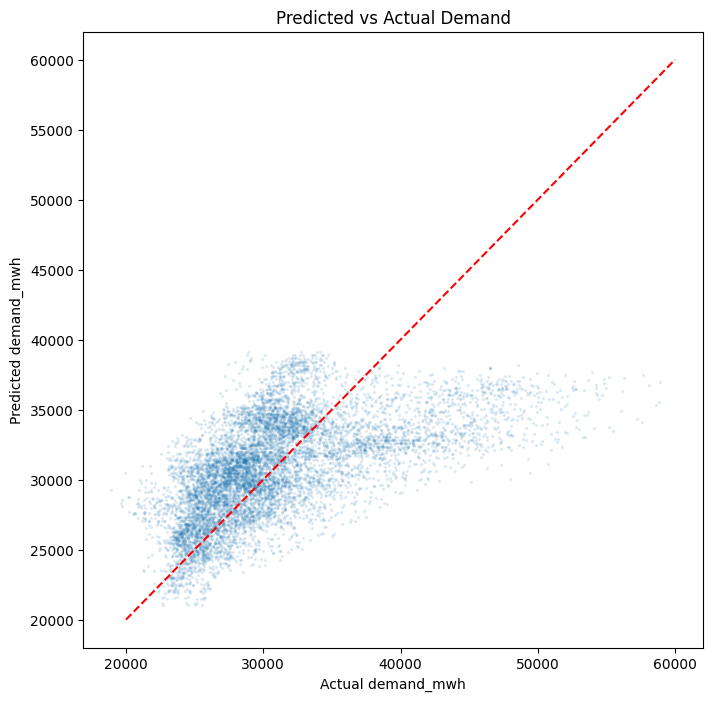

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df["demand_mwh"], model.fittedvalues, alpha=0.1, s=2)
ax.plot([20000, 60000], [20000, 60000], color='red', linestyle='--')  # perfect-fit reference line
ax.set_xlabel("Actual demand_mwh")
ax.set_ylabel("Predicted demand_mwh")
ax.set_title("Predicted vs Actual Demand")
plt.show()

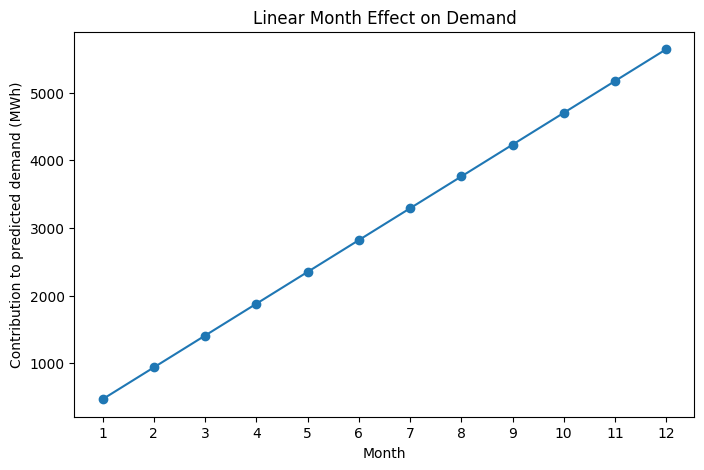

In [33]:
months = range(1, 13)
month_contribution = [model.params["month"] * m for m in months]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(months, month_contribution, marker='o')
ax.set_xlabel("Month")
ax.set_ylabel("Contribution to predicted demand (MWh)")
ax.set_title("Linear Month Effect on Demand")
ax.set_xticks(months)
plt.show()

In [34]:
model_v6 = smf.ols("demand_mwh ~ C(hour) + C(dayofweek) + C(month)", data=df).fit()
print(model_v6.rsquared)

0.7175909081681571


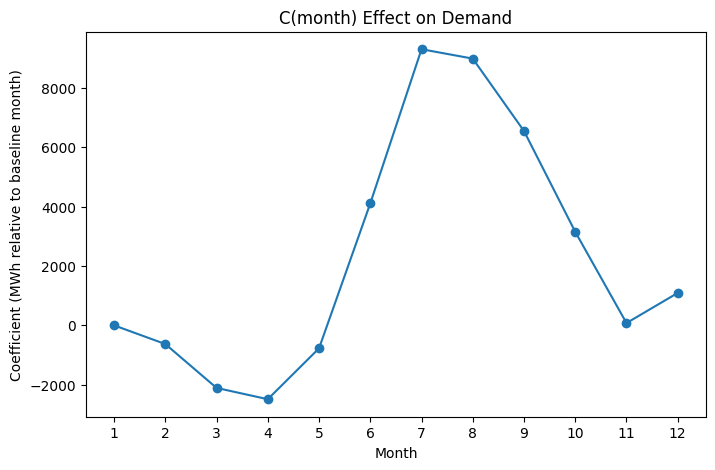

In [35]:
month_coefs = [model_v6.params.get(f"C(month)[T.{m}]", 0) for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 13), month_coefs, marker='o')
ax.set_xlabel("Month")
ax.set_ylabel("Coefficient (MWh relative to baseline month)")
ax.set_title("C(month) Effect on Demand")
ax.set_xticks(range(1, 13))
plt.show()

In [36]:
model_v6.rsquared

np.float64(0.7175909081681571)